# Week 11 - Machine vision for hydrofoil vapor clouds

**Run the existing detector, inspect its mistakes, and reproduce its evidence.**
This extension uses the author's existing 2026-09-12 cavitation code and results.
It accompanies the final cavitation section of [Lecture 11](../../lectures/week11_shock_vortex_identification.pdf).
Allow 30-45 minutes of teaching; default execution is CPU inference, not retraining.

Input: real CFD vapor-volume-fraction rasters and hydrofoil geometry. Output:
background, attached cavity and disconnected vapor cloud in 2-D. These are
**CFD fields, not experimental camera photographs**. The network already saw
the four TRAIN cases; the other three cases were also inspected during development.
This replay is not a new blind accuracy experiment.
<!-- FLOWMLLAB_COLAB_LAUNCH_V1 -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ehsan-Roohi/FlowMLLab/blob/main/notebooks/week11/W11_Cavitation_Cloud_Detection.ipynb)


**Multi-method extension:** compare our alpha-input detector, pressure threshold, pressure 3x3 model and two pressure U-Nets on the same 16 moving-case frames.

In [1]:
# FLOWMLLAB_COLAB_BOOTSTRAP_V1
# In Colab this cell obtains the complete repository and installs the tested package.
# In a local checkout it leaves the active environment and working directory unchanged.
from pathlib import Path as _FlowMLLabPath
import os as _flowmllab_os
import subprocess as _flowmllab_subprocess
import sys as _flowmllab_sys

if "google.colab" in _flowmllab_sys.modules or _flowmllab_os.environ.get("COLAB_RELEASE_TAG"):
    _flowmllab_root = _FlowMLLabPath("/content/FlowMLLab")
    if not (_flowmllab_root / ".git").is_dir():
        _flowmllab_subprocess.run(
            [
                "git", "clone", "--depth", "1",
                "https://github.com/Ehsan-Roohi/FlowMLLab.git", str(_flowmllab_root),
            ],
            check=True,
        )
    _flowmllab_subprocess.run(
        [
            _flowmllab_sys.executable, "-m", "pip", "install", "-q", "-e",
            f"{_flowmllab_root}[test,reconstruction]",
        ],
        check=True,
    )
    _flowmllab_notebook_dir = _flowmllab_root / "notebooks/week11"
    _flowmllab_os.chdir(_flowmllab_notebook_dir)
    for _flowmllab_path in (_flowmllab_root, _flowmllab_notebook_dir):
        if str(_flowmllab_path) not in _flowmllab_sys.path:
            _flowmllab_sys.path.insert(0, str(_flowmllab_path))
    print("FlowMLLab ready:", _flowmllab_root)


from pathlib import Path
import sys, time
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p/'flowmllab/cavitation_detection.py').is_file())
sys.path.insert(0, str(ROOT)) if str(ROOT) not in sys.path else None
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from flowmllab.cavitation_detection import (
    load_bundle, load_model, predict, scores, inputs, raster_baseline,
    comparison_figure, adapt_from_parent, digest)
torch.set_num_threads(2)
plt.rcParams.update({'font.size': 10, 'figure.dpi': 110})
DATA = ROOT/'data/week11_cavitation'
manifest, cases = load_bundle(DATA)
before = {name:digest(DATA/name) for name in manifest['files']}
model = load_model(DATA/'detector_weights.npz')
print('Model parameters:', sum(p.numel() for p in model.parameters()))
display(pd.DataFrame([{k:c[k] for k in ['name','role','frames']} for c in manifest['cases']]))

Model parameters: 126275


,name,role,frames
0,Case_13,TRAIN,18
1,Case_14,TRAIN,18
2,Case_16,TRAIN,18
3,Case1LES,TRAIN,32
4,Case_19,validation (inspected),27
5,Case_24,nontraining (previously inspected),27
6,Case_23,nontraining (previously inspected),18


## 1. What does the model see, and what is a reference?

The three channels are vapor fraction $\alpha_v$, a solid mask, and the
clipped distance to solid in raster pixels, $\min(d/48,1)$. The original
five encoder widths are 8, 16, 24, 32, 48; global average context is added
at the bottleneck. Bilinear upsampling and skip connections feed a three-logit
head. A softmax/argmax assigns mutually exclusive classes. Unlike overlapping
shock/vortex labels, attached and detached are alternative topology states.

The weak teacher was constructed on the **original Fluent cell-face graph**:
support is $\alpha_v\geq0.20$; a connected component touching an actual wall
face is attached. External/crop-uncertain support and solid are ignored (255).
These algorithmic labels are not independent human truth. The exact native
references are supplied; this lab does not approximate them with pixel dilation.

**Predict before running:** Can a thin, poorly resolved ligament change the
class of an entire vapor region? Does a bright vapor region alone establish
that the cloud is detached, or that a shedding event occurred?

In [2]:
case = cases['Case1LES']
example = inputs(case['alpha'][22], case['wall'])
assert example.shape[0] == 3
assert np.all(example[0][case['wall']] == 0)
print('Input tensor:', example.shape, '| reference classes:', np.unique(case['reference']))
print('Weights source SHA-256:', manifest['source_checkpoint_sha256'])

Input tensor: (3, 192, 384) | reference classes: [  0   1   2 255]
Weights source SHA-256: e2ffa88b33582b99de7aff6396e9116949aef1bda87fac296454f7e00b97e921


## 2. Rerun all seven cases with the frozen detector

Only the three input channels enter `predict`. Native labels are read afterward
for evaluation. There is no connectivity repair, gap filling, reference masking
or geometry veto applied to neural output. We compare every predicted pixel to
the stored original prediction, and recompute pooled Dice from TP, FP and FN.
Empty-versus-empty has undefined Dice (`None`), not a fabricated perfect score.
Solid/uncertain reference pixels are excluded; wall false positives are counted separately.

In [3]:
predictions, rows = {}, []
started = time.perf_counter()
for entry in manifest['cases']:
    name = entry['name']; c = cases[name]
    p = predict(model, c['alpha'], c['wall'])
    predictions[name] = p
    np.testing.assert_array_equal(p, c['archived_prediction'])
    measured = scores(p, c['reference'])
    assert measured == entry['archived_metrics']
    rows.append({'case':name, 'role':c['role'], 'frames':len(p),
                 'attached Dice':measured['attached_2d']['dice'],
                 'cloud Dice':measured['disconnected_2d']['dice'],
                 'wall positive pixels':int(((p>0)&c['wall']).sum())})
display(pd.DataFrame(rows))
print('Exact archived replay:', sum(len(p) for p in predictions.values()), 'frames')
print('Local inference seconds:', round(time.perf_counter()-started, 2))

,case,role,frames,attached Dice,cloud Dice,wall positive pixels
0,Case_13,TRAIN,18,0.989712,0.973966,128
1,Case_14,TRAIN,18,0.978803,0.952756,105
2,Case_16,TRAIN,18,0.976685,0.880488,115
3,Case1LES,TRAIN,32,0.933232,0.887129,44
4,Case_19,validation (inspected),27,0.969395,0.568082,80
5,Case_24,nontraining (previously inspected),27,0.962702,0.491878,73
6,Case_23,nontraining (previously inspected),18,0.979947,0.855246,131


Exact archived replay: 158 frames
Local inference seconds: 7.31


## 3. Read the cavity and its detection in the same figure

The left column is the CFD vapor field; the middle is the native weak reference;
the right is fresh neural inference. Orange is attached, magenta is disconnected
in 2-D. All panels use the same [0,1] vapor colors and physical coordinates.
Grey reference support is uncertain; the solid is shown separately.
The two lead frames (0.36 and 2.12 s) belong to the TRAIN LES trajectory and
were already in the original review. This figure illustrates the task, not generalization.

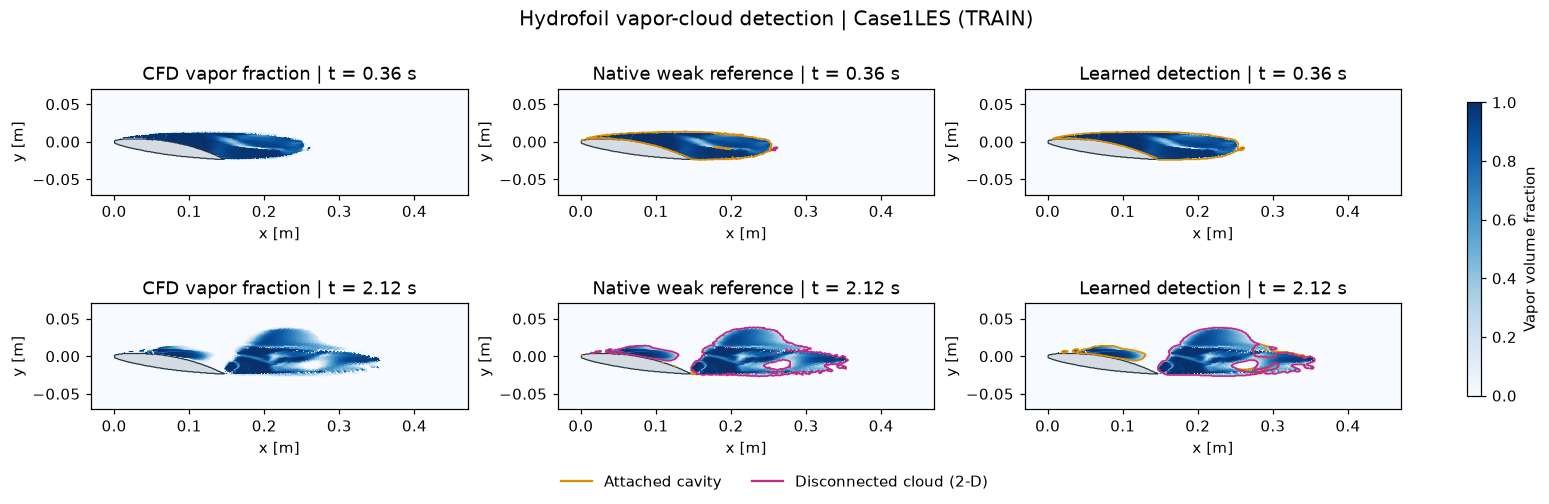

In [4]:
comparison_figure(cases['Case1LES'], predictions['Case1LES'], [0,22],
                  'Hydrofoil vapor-cloud detection | Case1LES (TRAIN)')
plt.show()

## 4. Retain the difficult nontraining case

Case 24 is excluded from gradient training but was previously inspected.
Its pooled cloud Dice is much lower than its attached-cavity Dice. The original
worst-error frame at 2.00 s is retained below beside an earlier frame.
A high attached score does not establish reliable detection of detached clouds.
Compare the physical width of a missed ligament to raster spacing before
claiming improved topology. Pixel-distance preprocessing is not resolution invariant.

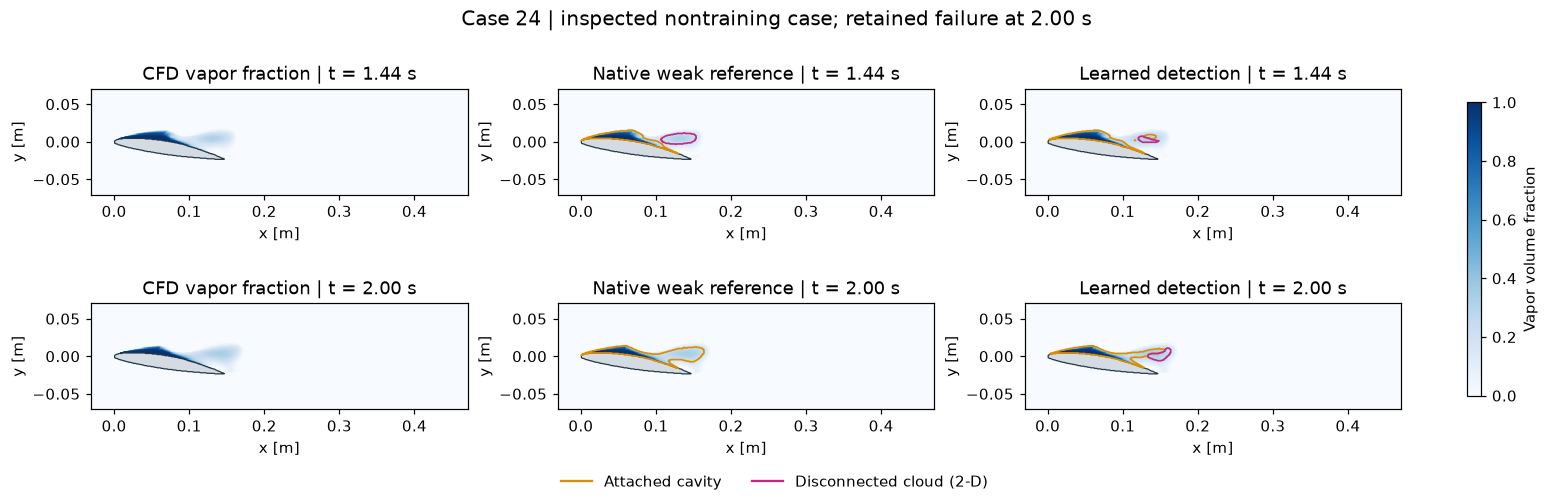

In [5]:
comparison_figure(cases['Case_24'], predictions['Case_24'], [17,24],
                  'Case 24 | inspected nontraining case; retained failure at 2.00 s')
plt.show()

## 5. A transparent comparator and a negative control

A four-connected raster threshold at 0.20 plus one-cell wall contact is a
**separate classical baseline**, not the native-mesh teacher and not a neural
postprocessor. Report its disagreements instead of assuming the network wins.
Then remove all vapor while keeping the same geometry: any positive prediction
is a false detection in this negative control.

In [6]:
baseline_rows = []
for name, c in cases.items():
    baseline = np.stack([raster_baseline(a, c['wall']) for a in c['alpha']])
    m = scores(baseline, c['reference'])
    zero = predict(model, np.zeros_like(c['alpha'][0]), c['wall'])
    assert np.count_nonzero(zero) == 0
    baseline_rows.append({'case':name, 'raster attached Dice':m['attached_2d']['dice'],
                          'raster cloud Dice':m['disconnected_2d']['dice'],
                          'zero-vapor positives':int((zero>0).sum())})
display(pd.DataFrame(baseline_rows))

,case,raster attached Dice,raster cloud Dice,zero-vapor positives
0,Case_13,1.000000,1.000000,0
1,Case_14,1.000000,1.000000,0
2,Case_16,1.000000,1.000000,0
3,Case1LES,0.973989,0.957985,0
4,Case_19,1.000000,1.000000,0
5,Case_24,1.000000,1.000000,0
6,Case_23,1.000000,1.000000,0


## 6. A seeded noise challenge, not a new accuracy claim

Add Gaussian noise with fixed standard deviation 0.02 to the supplied vapor
channel, clip to [0,1], and retain geometry. Compare against the same clean
reference. This is an input-perturbation sensitivity exercise; it is not an
experimental camera-noise model or a new independent physical validation set.
Do not select a model or alter thresholds from this already-inspected result.

In [7]:
rng = np.random.default_rng(20260916)
c = cases['Case1LES']; i = 22
noisy = np.clip(c['alpha'][i] + rng.normal(0,.02,c['wall'].shape),0,1).astype('float32')
p_noisy = predict(model, noisy, c['wall'])
display(pd.DataFrame({'clean': {k:v['dice'] for k,v in scores(predictions[c['name']][i:i+1],c['reference'][i:i+1]).items()},
                     'noisy': {k:v['dice'] for k,v in scores(p_noisy,c['reference'][i:i+1]).items()}}))
print('Changed labels:', int((p_noisy[0]!=predictions[c['name']][i]).sum()))

,clean,noisy
attached_2d,0.000000,0.000000
disconnected_2d,0.885679,0.885082


Changed labels: 54


## 7. Optional: rerun the original final adaptation stage

Default Run All keeps this off. The supplied parent is the original native_v4
model, trained with $\alpha_v\geq0.50$ references. The displayed v6 result used
**1000 additional** Adam updates at 0.0002 with the revised 0.20 references,
after 2000 parent updates. This is not a 1000-step model trained from scratch.
The four complete TRAIN cases, balanced cloud-frame sampling, vertical reflection,
weighted cross entropy plus foreground Dice, and gradient clipping are preserved.
Validation was monitored; the fixed final step was selected. There was no fresh
test after this development correction. No PDE loss or temporal predictor is used.

Set `RUN_ADAPTATION=True` for the full final-stage rerun (several CPU minutes).
It returns a separate in-memory model. It cannot overwrite the supplied weights.
Different PyTorch builds may produce different optimization trajectories.
A short changed budget is an exercise, not reproduction of the published v6 model.

In [8]:
RUN_ADAPTATION = False
if RUN_ADAPTATION:
    parent = load_model(DATA/'parent_weights.npz')
    adapted_model, training_history = adapt_from_parent(parent, cases, manifest['protocol'])
    display(pd.DataFrame(training_history))
    validation = cases['Case_19']
    adapted = predict(adapted_model, validation['alpha'], validation['wall'])
    print('Validation weak-reference agreement:', scores(adapted, validation['reference']))
else:
    print('Optional training skipped; the displayed results use the original frozen v6 weights.')
assert before == {name:digest(DATA/name) for name in manifest['files']}
print('Retained inputs and weights unchanged.')

Optional training skipped; the displayed results use the original frozen v6 weights.
Retained inputs and weights unchanged.


## 8. Compare our alpha, pressure and U-Net methods on identical frames

This second retained campaign is from 2026-09-13. It includes the original
alpha-input context U-Net continued on moving cases, a fixed pressure threshold,
the pressure-only 3x3 model, pressure-only U-Net, and pressure-only topology U-Net.
The two whole nontraining trajectories are Plunging3 (7 frames) and Oscillation3
(9 frames); both were inspected in earlier development. They contain no valid
attached-reference pixels, so they cannot validate attached-class generalization.

Pressure input is $p_{gauge}+p_{operating}-p_{v,configured}$ in Pa, represented
at asinh scales 10/100/1000/10000 Pa, plus geometry. **Alpha is not supplied to
any pressure model.** The classical threshold is $p_{abs}<p_v$. Scalar pressure
models predict total vapor support at $\hat\alpha\geq0.20$; only the two topology
networks directly distinguish attached from detached. We compare common total
support here, not cloud identity for models that do not predict it.

All three original pressure seeds (11,22,33) are replayed. Plots use the first
declared seed and the largest valid CFD cavity area, not the best model score. The alpha model
has a different input advantage and training history: this is an explanation
of different methods, not a matched-input architecture ranking.

In [9]:
from flowmllab.cavitation_methods import (
    load_comparison, infer_comparison, method_mask, binary_score, methods_figure)
METHODS_DATA = ROOT/'data/week11_cavitation_methods'
methods_manifest, frames = load_comparison(METHODS_DATA)
methods_before = {n:digest(METHODS_DATA/n) for n in methods_manifest['files']}
method_names = ['alpha_topology','pressure_threshold','pressure_patch','pressure_unet','pressure_topology']
comparison_rows = []
for seed in methods_manifest['seeds']:
    outputs = infer_comparison(METHODS_DATA,frames,seed)
    if seed == 11:
        plot_outputs = outputs
    for f,o in zip(frames,outputs):
        np.testing.assert_array_equal(o['alpha_topology'],f['expected_alpha_topology'])
        for method in method_names[2:]:
            actual = o[method] if method == 'pressure_topology' else o[method]>=.20
            np.testing.assert_array_equal(actual,f[f'expected_{method}_{seed}'])
    for case_name in methods_manifest['cases']:
        members = [(f,o) for f,o in zip(frames,outputs) if f['case']==case_name]
        for method in method_names:
            if seed != 11 and method in method_names[:2]:
                continue
            counts = np.zeros(3,dtype='int64')
            for f,o in members:
                valid = (f['reference']!=255)&~f['wall']
                v = binary_score(method_mask(method,o[method]),f['alpha']>=.20,valid)
                counts += [v['tp'],v['fp'],v['fn']]
            tp,fp,fn = counts
            comparison_rows.append({'case':case_name,'method':method,'seed':seed,
                                    'total-cavity Dice':2*tp/(2*tp+fp+fn)})
method_metrics = pd.DataFrame(comparison_rows)
display(method_metrics)
display(method_metrics.groupby(['case','method'])['total-cavity Dice'].agg(['mean','std','count']))
print('All 16 shared frames and three pressure seeds reproduce the archived binary predictions.')

,case,method,seed,total-cavity Dice
0,Plunging3,alpha_topology,11,0.949153
1,Plunging3,pressure_threshold,11,0.838732
2,Plunging3,pressure_patch,11,0.868508
3,Plunging3,pressure_unet,11,0.839437
4,Plunging3,pressure_topology,11,0.824236
5,Oscillation3,alpha_topology,11,0.934363
6,Oscillation3,pressure_threshold,11,0.779935
7,Oscillation3,pressure_patch,11,0.911111
8,Oscillation3,pressure_unet,11,0.868293
9,Oscillation3,pressure_topology,11,0.856481


mean       std  count
case         method                                       
Oscillation3 alpha_topology      0.934363       NaN      1
             pressure_patch      0.910902  0.004507      3
             pressure_threshold  0.779935       NaN      1
             pressure_topology   0.799701  0.066247      3
             pressure_unet       0.793538  0.068181      3
Plunging3    alpha_topology      0.949153       NaN      1
             pressure_patch      0.871132  0.002581      3
             pressure_threshold  0.838732       NaN      1
             pressure_topology   0.770741  0.063684      3
             pressure_unet       0.759312  0.071902      3

All 16 shared frames and three pressure seeds reproduce the archived binary predictions.


## 9. The homepage comparison: alpha versus pressure methods

Every panel uses the same CFD field, geometry and time. CFD alpha is the
background for visual comparison only; it never enters pressure inference.
Orange/magenta are attached/disconnected classes. Green is total cavity only.
These are different output semantics, not interchangeable cloud labels.
The panel Dice values describe this one frame; the table above pools the
complete two trajectories and retains all pressure seeds.

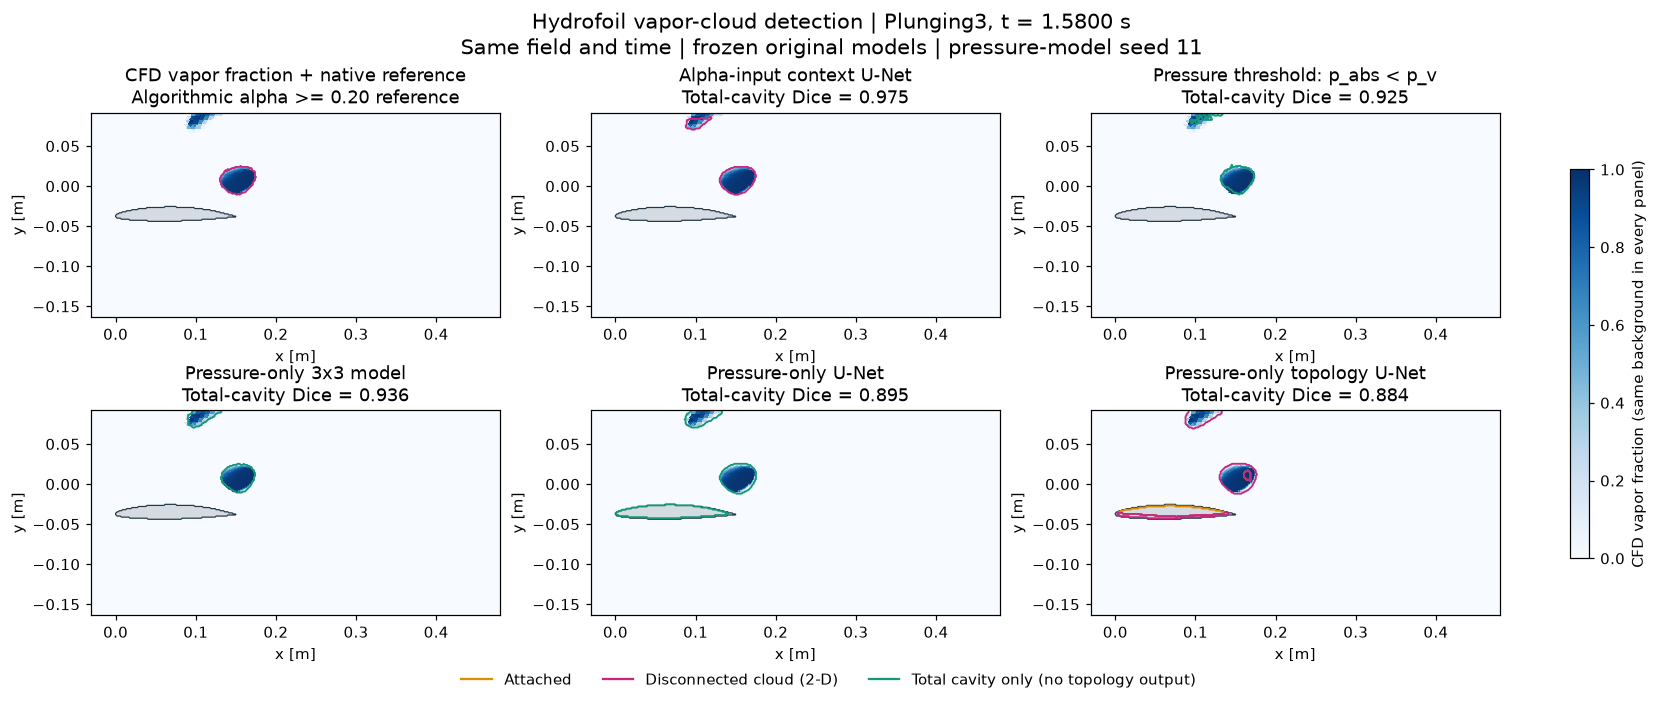

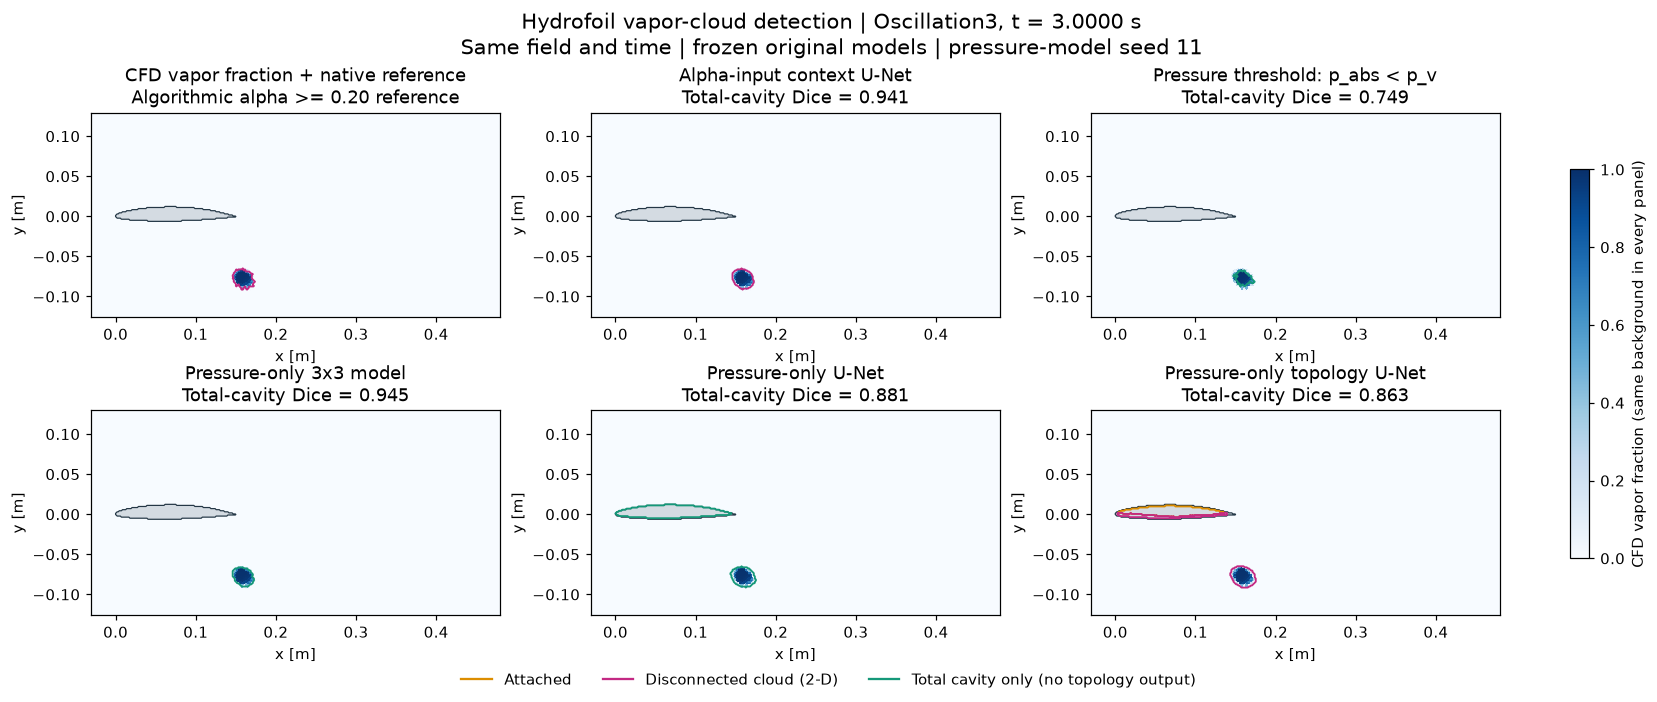

In [10]:
for case_name in methods_manifest['cases']:
    ids = [i for i,f in enumerate(frames) if f['case']==case_name]
    i = max(ids,key=lambda j:int(((frames[j]['alpha']>=.20)&(frames[j]['reference']!=255)&~frames[j]['wall']).sum()))
    methods_figure(frames[i],plot_outputs[i])
    plt.show()
assert methods_before == {n:digest(METHODS_DATA/n) for n in methods_manifest['files']}

**Interpretation:** More spatial context did not uniformly improve the original
pressure experiments. Keep the U-Net and topology variants as comparisons,
including their errors. A pressure deficit is a useful feature but is not a
cavitation transport law; neither model forecasts shedding or tracks cloud identity.
Pressure sensitivity remains: in the original 3x3 campaign, the three-seed
Plunging3 total-cavity Dice fell from 0.8711 on clean pressure to 0.7357 at
1000-Pa input-noise SD. Oscillation3 fell from 0.9109 to 0.8181. Those retained
noise experiments are documented in the comparison manifest; this gallery
replays the clean same-frame comparison.

[Multi-method data and checkpoint provenance](../../data/week11_cavitation_methods/README.md) ·
[All method code](../../flowmllab/cavitation_methods.py) ·
[Original campaign metadata](../../data/week11_cavitation_methods/manifest.json).

## Exit assessment and sources

1. Explain why a vapor-fraction threshold does not by itself identify attachment.
2. Mark one wrong attached/cloud decision in the displayed nontraining case.
3. Compare the raster baseline and neural model using both classes, including wall errors.
4. Specify the expert labels, new trajectories, geometric tests and temporal cadence
   you would need for a defensible detached-cloud tracking or shedding-event claim.

**Our source:** Ehsan Roohi, author hydrofoil cavitation computer-vision experiment,
2026-09-12, `native_alpha20_v6`; exact checkpoint, data and source-code hashes in
[the manifest](../../data/week11_cavitation/manifest.json).
[Code](../../flowmllab/cavitation_detection.py) ·
[Full results and limitations](../../results/week11_cavitation/README.md).

**Related work:** Hatzissawidis et al., *Deep learning semantic segmentation for
cloud cavitation image analysis*, Physics of Fluids 38, 093331 (2026),
[doi:10.1063/5.0345365](https://doi.org/10.1063/5.0345365).
That study segments camera images and then uses a heuristic sheet/cloud split;
our retained CFD experiment directly predicts three classes. This course lab
does not reproduce their data, code, results or claim superiority to their method.

Original course adaptation and verification are AI-assisted. Full CFD solver
regeneration, mesh convergence, expert ground truth and forecasting are outside
this replay. Continue to [Week 12](../week12/README.md).